# Nexterra MOF Reward Pipeline

This notebook is the main sequential orchestrator. Core logic stays in `src/`; this notebook only coordinates reproducible pipeline scripts.

## Execution Sequence

1. Step 1: Environment and shared config from `src.constants`
2. Step 2: Build labeled acute toxicity dataset
3. Step 3: Build acute-tox RDKit feature table (script emits real progress)
4. Step 4: Build reusable drug-tox space artifact (script emits real progress)
5. Step 5: Validate required inputs
6. Step 6: Score MOF linker candidates
7. Step 7: Score one example SMILES
8. Step 8: Test on experimental validation set
9. Step 9: Building the plots

## References
- Delaney, J. S. ESOL: Estimating Aqueous Solubility Directly from Molecular Structure (J. Chem. Inf. Comput. Sci., 2004). DOI: 10.1021/ci034243x.
- Principles and Procedures for Assessment of Acute Toxicity Incorporating In Silico Methods (PMC9934006). Table 2 summarizes UN GHS acute toxicity LD50 thresholds.
- Baell, J. B.; Holloway, G. A. New Substructure Filters for Removal of PAINS (J. Med. Chem., 2010). DOI: 10.1021/jm901137j.
- Brenk, R. et al. Lessons Learnt from Assembling Screening Libraries (ChemMedChem, 2007/2008). DOI: 10.1002/cmdc.200700139.
- RDKit FilterCatalog documentation (PAINS/BRENK/NIH alert sets).
- Synthesis and Biomedical Applications of Highly Porous MOFs (MDPI 2022) ? isoreticular expansion via longer linkers increases pore dimensions.

## Step 1: Environment and Shared Config

In [2]:
from __future__ import annotations

from pathlib import Path
import importlib
import runpy
import subprocess
import sys
import pandas as pd

ROOT = Path.cwd().resolve()
REPO_ROOT = ROOT if (ROOT / 'src').exists() else ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Force reload of src modules to pick up local edits without restarting kernel
import src.constants as _src_constants
importlib.reload(_src_constants)

# If these modules were imported earlier in the session, refresh them to avoid stale symbols.
try:
    import src.drug_tox_space as _src_drug_tox_space
    importlib.reload(_src_drug_tox_space)
except Exception:
    pass

try:
    import src.MOF_bio_reward as _src_mof_bio_reward
    importlib.reload(_src_mof_bio_reward)
except Exception:
    pass

from src.constants import (
    ACUTE_TOX_IV_PATH,
    DRUG_TOX_SPACE_FULL_PATH,
    INTERIM_DIR,
    MOF_PROPERTIES_COLS,
    MOF_SMILES_FILENAME,
    MOF_SMILES_PATH,
)

# Notebook-only switches (paths and column names remain centralized in src.constants)
FORCE_REBUILD_ACUTE_LABELS: bool = False
FORCE_REBUILD_RDKIT_FEATURES: bool = False
FORCE_REBUILD_TOX_SPACE: bool = True
FORCE_REBUILD_REWARD_SCORES: bool = True

# 100 = sample 100 random unique smiles; 0 = process whole input file
RANDOM_UNIQUE_SMILES_SAMPLE_N: int = 25000
RANDOM_UNIQUE_SMILES_SAMPLE_SEED: int = 42

ACUTE_TOX_LABELED_PATH: Path = INTERIM_DIR / 'acute_tox_iv_labeled.parquet'
ACUTE_TOX_RDKIT_FEATURES_PATH: Path = INTERIM_DIR / 'acute_tox_iv_rdkit_features.parquet'
GENERATED_LINKER_SCORES_PATH: Path = INTERIM_DIR / 'generated_linker_scores.parquet'


def run_script(script_rel_path: str) -> None:
    script_path = REPO_ROOT / script_rel_path
    if not script_path.exists():
        raise FileNotFoundError(f'Script not found: {script_path}')
    cmd = [sys.executable, '-u', str(script_path)]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=str(REPO_ROOT))


print('Python executable:', sys.executable)
print('Repository root:', REPO_ROOT)
print('Acute tox source:', ACUTE_TOX_IV_PATH)
print('MOF source file:', MOF_SMILES_FILENAME)
print('MOF source path:', MOF_SMILES_PATH)
print('Tox-space artifact:', DRUG_TOX_SPACE_FULL_PATH)
print('Random unique smiles sample size (0=all):', RANDOM_UNIQUE_SMILES_SAMPLE_N)
print('Random sample seed:', RANDOM_UNIQUE_SMILES_SAMPLE_SEED)



Python executable: /opt/anaconda3/envs/nexerra/bin/python
Repository root: /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio
Acute tox source: /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/data/raw/Acute Toxicity_mouse_intravenous_LD50_with_units.csv
MOF source file: train_smiles.csv
MOF source path: /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/data/raw/train_smiles.csv
Tox-space artifact: /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/data/processed/drug_tox_space_full.npz
Random unique smiles sample size (0=all): 25000
Random sample seed: 42


## Step 2: Build Labeled Acute Toxicity Dataset

In [2]:
if FORCE_REBUILD_ACUTE_LABELS or not ACUTE_TOX_LABELED_PATH.exists():
    run_script('scripts/build_acute_tox_labeled.py')
else:
    print(f'Reusing existing file: {ACUTE_TOX_LABELED_PATH}')

acute_tox_labeled_df = pd.read_parquet(ACUTE_TOX_LABELED_PATH)
print('acute_tox_labeled_df shape:', acute_tox_labeled_df.shape)
acute_tox_labeled_df.head(3)


Reusing existing file: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\acute_tox_iv_labeled.parquet
acute_tox_labeled_df shape: (16498, 9)


,TAID,Name,IUPAC Name,PubChem CID,Canonical SMILES,InChIKey,Toxicity Value,ghs_category,ghs_toxic
0,TOX-245,thiotepa,tris(aziridin-1-yl)-sulfanylidene-lambda5-phos...,5453,S=P(N1CC1)(N1CC1)N1CC1,FOCVUCIESVLUNU-UHFFFAOYSA-N,14.499693,2,True
1,TOX-1279,metformin,"3-(diaminomethylidene)-1,1-dimethylguanidine",4091,CN(C)C(=N)N=C(N)N,XZWYZXLIPXDOLR-UHFFFAOYSA-N,179.990245,3,True
2,TOX-1281,<NA>,3-phenylprop-2-enoic acid,8784,O=C(O)C=Cc1ccccc1,WBYWAXJHAXSJNI-UHFFFAOYSA-N,379.997435,4,True


## Step 3: Build Acute-Tox RDKit Features

In [3]:
if FORCE_REBUILD_RDKIT_FEATURES or not ACUTE_TOX_RDKIT_FEATURES_PATH.exists():
    script_path = REPO_ROOT / 'scripts' / 'extract_rdkit_features.py'
    print('Running in-kernel for live progress:', script_path)
    runpy.run_path(str(script_path), run_name='__main__')
else:
    print(f'Reusing existing file: {ACUTE_TOX_RDKIT_FEATURES_PATH}')

acute_tox_rdkit_df = pd.read_parquet(ACUTE_TOX_RDKIT_FEATURES_PATH)
print('acute_tox_rdkit_df shape:', acute_tox_rdkit_df.shape)
acute_tox_rdkit_df.head(10)


Reusing existing file: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\acute_tox_iv_rdkit_features.parquet
acute_tox_rdkit_df shape: (16498, 68)


,TAID,Name,IUPAC Name,PubChem CID,Canonical SMILES,InChIKey,Toxicity Value,ghs_category,ghs_toxic,MolecularWeight,...,NHOHCount,NOCount,NumAmideBonds,FpDensityMorgan1,VanDerWaalsVolume,DipoleMoment,QED,LipinskiRO5,ECFP4,MACCS
0,TOX-245,thiotepa,tris(aziridin-1-yl)-sulfanylidene-lambda5-phos...,5453,S=P(N1CC1)(N1CC1)N1CC1,FOCVUCIESVLUNU-UHFFFAOYSA-N,14.499693,2,True,189.224,...,0,3,0,0.727273,230.437392,0.336011,0.461380,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,TOX-1279,metformin,"3-(diaminomethylidene)-1,1-dimethylguanidine",4091,CN(C)C(=N)N=C(N)N,XZWYZXLIPXDOLR-UHFFFAOYSA-N,179.990245,3,True,129.167,...,5,5,0,1.444444,168.104528,0.153263,0.281874,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,TOX-1281,<NA>,3-phenylprop-2-enoic acid,8784,O=C(O)C=Cc1ccccc1,WBYWAXJHAXSJNI-UHFFFAOYSA-N,379.997435,4,True,148.161,...,1,2,0,1.272727,216.412799,0.382113,0.648920,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,TOX-1282,CARVACROL,2-methyl-5-propan-2-ylphenol,10364,Cc1ccc(C(C)C)cc1O,RECUKUPTGUEGMW-UHFFFAOYSA-N,79.999467,3,True,150.221,...,1,1,0,1.272727,221.393794,0.381673,0.652274,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,TOX-1288,Allicin,3-prop-2-enylsulfinylsulfanylprop-1-ene,65036,C=CCSS(=O)CC=C,JDLKFOPOAOFWQN-UHFFFAOYSA-N,60.007764,3,True,162.279,...,0,1,0,1.444444,187.933738,0.587236,0.452389,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
5,TOX-1289,PAEONOL,1-(2-hydroxy-4-methoxyphenyl)ethanone,11092,COc1ccc(C(C)=O)c(O)c1,UILPJVPSNHJFIK-UHFFFAOYSA-N,195.992923,3,True,166.176,...,1,3,0,1.500000,232.011330,1.071229,0.678617,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,TOX-1292,Glucoxy,"2-(3,4-dihydroxy-5-oxooxolan-2-yl)-2-hydroxyac...",219402,O=CC(O)C1OC(=O)C(O)C1O,UYUXSRADSPPKRZ-UHFFFAOYSA-N,4585.895845,5,False,176.124,...,3,6,0,1.500000,217.068344,0.684908,0.309751,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,TOX-1297,scopoletin,7-hydroxy-6-methoxychromen-2-one,5280460,COc1cc2ccc(=O)oc2cc1O,RODXRVNMMDRFIK-UHFFFAOYSA-N,350.000000,4,True,192.170,...,1,4,0,1.357143,268.189387,1.134645,0.695448,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,TOX-1298,(E/Z)-ferulic acid,3-(4-hydroxy-3-methoxyphenyl)prop-2-enoic acid,709,COc1cc(C=CC(=O)O)ccc1O,KSEBMYQBYZTDHS-UHFFFAOYSA-N,856.973520,4,True,194.186,...,2,4,0,1.500000,268.189387,0.552159,0.715320,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,TOX-1307,<NA>,"1-ethenyl-1-methyl-2,4-bis(prop-1-en-2-yl)cycl...",10583,C=CC1(C)CCC(C(=C)C)CC1C(=C)C,OPFTUNCRGUEPRZ-UHFFFAOYSA-N,269.990752,3,True,204.357,...,0,0,0,1.266667,308.692894,0.068137,0.582048,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Step 4: Build Reusable Drug-Tox Space

In [4]:
if FORCE_REBUILD_TOX_SPACE or not DRUG_TOX_SPACE_FULL_PATH.exists():
    script_path = REPO_ROOT / 'scripts' / 'build_drug_tox_space.py'
    print('Running in-kernel for live progress:', script_path)
    runpy.run_path(str(script_path), run_name='__main__')
else:
    print(f'Reusing existing tox-space artifact: {DRUG_TOX_SPACE_FULL_PATH}')

if not DRUG_TOX_SPACE_FULL_PATH.exists():
    raise FileNotFoundError(f'Missing tox-space artifact: {DRUG_TOX_SPACE_FULL_PATH}')

print('Tox-space ready:', DRUG_TOX_SPACE_FULL_PATH)


Running in-kernel for live progress: C:\Users\ivan\Projects\PhD.NexterraReward\scripts\build_drug_tox_space.py


Tox descriptors:   0%|          | 0/48889 [00:00<?, ?it/s]

[02:42:10] UFFTYPER: Unrecognized charge state for atom: 3
[02:42:20] UFFTYPER: Unrecognized charge state for atom: 3
[02:42:31] UFFTYPER: Unrecognized charge state for atom: 5
[02:42:53] UFFTYPER: Unrecognized charge state for atom: 4
[02:42:57] UFFTYPER: Unrecognized charge state for atom: 7
[02:43:31] UFFTYPER: Unrecognized charge state for atom: 1
[02:43:31] UFFTYPER: Unrecognized charge state for atom: 6
[02:43:31] UFFTYPER: Unrecognized charge state for atom: 6
[02:43:37] UFFTYPER: Unrecognized charge state for atom: 4
[02:43:48] UFFTYPER: Unrecognized charge state for atom: 3
[02:43:52] UFFTYPER: Unrecognized atom type: Se2+2 (9)
[02:43:52] UFFTYPER: Unrecognized atom type: Se2+2 (9)
[02:43:58] UFFTYPER: Unrecognized charge state for atom: 4
[02:44:10] UFFTYPER: Unrecognized charge state for atom: 14
[02:44:10] UFFTYPER: Unrecognized atom type: Pb3+3 (14)
[02:44:12] UFFTYPER: Unrecognized charge state for atom: 5
[02:44:18] UFFTYPER: Unrecognized charge state for atom: 1
[02:44:

Tox fingerprints:   0%|          | 0/48889 [00:00<?, ?it/s]

Saved: C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\drug_tox_space_full.npz
Saved: C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\drug_tox_space.json
Saved: C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\drug_tox_fragments.csv
Tox-space ready: C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\drug_tox_space_full.npz


## Step 5: Validate Required Inputs

In [3]:
mof_df = pd.read_csv(MOF_SMILES_PATH)
smiles_col = MOF_PROPERTIES_COLS['branch_smiles']
required_mof_cols = [smiles_col]
missing = [c for c in required_mof_cols if c not in mof_df.columns]
if missing:
    raise ValueError(f'MOF input is missing required columns: {missing}')

if RANDOM_UNIQUE_SMILES_SAMPLE_N < 0:
    raise ValueError('RANDOM_UNIQUE_SMILES_SAMPLE_N must be >= 0 (0 means use all smiles).')

SCORING_INPUT_PATH = MOF_SMILES_PATH
if RANDOM_UNIQUE_SMILES_SAMPLE_N == 0:
    scoring_df = mof_df
    unique_count = int(
        mof_df[smiles_col].astype(str).str.strip().replace('', pd.NA).dropna().nunique()
    )
    print('Sampling disabled. Using full input file.')
else:
    smiles_series = mof_df[smiles_col].astype(str).str.strip()
    unique_smiles = smiles_series.replace('', pd.NA).dropna().drop_duplicates().reset_index(drop=True)
    sample_n = min(RANDOM_UNIQUE_SMILES_SAMPLE_N, len(unique_smiles))
    if sample_n == 0:
        raise ValueError('No valid non-empty smiles found to sample from input file.')
    sampled_smiles = unique_smiles.sample(n=sample_n, random_state=RANDOM_UNIQUE_SMILES_SAMPLE_SEED)
    scoring_df = pd.DataFrame({smiles_col: sampled_smiles.reset_index(drop=True)})
    SCORING_INPUT_PATH = INTERIM_DIR / f'mof_unique_smiles_sample_{sample_n}.csv'
    scoring_df.to_csv(SCORING_INPUT_PATH, index=False)
    unique_count = len(unique_smiles)
    print(f'Random unique sample written to: {SCORING_INPUT_PATH}')

print('MOF rows (raw):', len(mof_df))
print('Unique smiles (raw):', unique_count)
print('Scoring rows:', len(scoring_df))
print('Scoring input path:', SCORING_INPUT_PATH)
print('Scoring column:', smiles_col)
scoring_df[[smiles_col]].head(3)


Random unique sample written to: /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/data/interim/mof_unique_smiles_sample_25000.csv
MOF rows (raw): 898450
Unique smiles (raw): 898450
Scoring rows: 25000
Scoring input path: /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/data/interim/mof_unique_smiles_sample_25000.csv
Scoring column: smiles


,smiles
0,O=S(O)c1c[c]([Lr])nc(F)c1-c1cc(S(=O)Oc2ccncc2)...
1,BrC(=C=CC(Br)(Br)C[Lr])C[Lr]
2,Cc1c(S(=O)(=O)O)[c]([Lr])c2csnc2[c]1[Lr]


## Step 6: Score `branch_smiles`

In [6]:
print('Batch scoring input:', SCORING_INPUT_PATH)

if FORCE_REBUILD_REWARD_SCORES or not GENERATED_LINKER_SCORES_PATH.exists():
    script_path = REPO_ROOT / 'scripts' / 'score_bio_reward_batch.py'
    argv_backup = sys.argv[:]
    sys.argv = [
        str(script_path),
        '--input-file',
        str(SCORING_INPUT_PATH),
        '--smiles-col',
        MOF_PROPERTIES_COLS['branch_smiles'],
        '--output',
        str(GENERATED_LINKER_SCORES_PATH),
        '--context-mode',
        'reuse',
        '--tox-space-path',
        str(DRUG_TOX_SPACE_FULL_PATH),
    ]
    try:
        print('Running in-kernel for live progress:', ' '.join(sys.argv))
        runpy.run_path(str(script_path), run_name='__main__')
    finally:
        sys.argv = argv_backup
else:
    print(f'Reusing existing scores file: {GENERATED_LINKER_SCORES_PATH}')

scores_df = pd.read_parquet(GENERATED_LINKER_SCORES_PATH)
component_cols = [c for c in scores_df.columns if c.startswith('component_')]
feature_cols = [c for c in scores_df.columns if c.startswith('feature_')]

print('Saved scores:', GENERATED_LINKER_SCORES_PATH)
print('Rows:', len(scores_df))
print('Component columns:', len(component_cols))
print('Feature columns:', len(feature_cols))

preview_cols = ['row', 'branch_smiles', 'linker_smiles', 'total_score'] + component_cols[:4]
scores_df[preview_cols].head(5)


Batch scoring input: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\mof_unique_smiles_sample_25000.csv
Running in-kernel for live progress: C:\Users\ivan\Projects\PhD.NexterraReward\scripts\score_bio_reward_batch.py --input-file C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\mof_unique_smiles_sample_25000.csv --smiles-col smiles --output C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\generated_linker_scores.parquet --context-mode reuse --tox-space-path C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\drug_tox_space_full.npz
Deduplicated SMILES before scoring: 25000 input -> 25000 unique
Context stats source: fixed_constants
Context linker_stats: {'heavy_atom_count': (1.0, 50.0), 'anchor_distance': (1.45, 33.35)}
Context mof_stats: {'agsa': (0.0, 9463.0), 'pld': (0.0, 101.0), 'lcd': (0.3, 117.0)}
Saved context stats artifact: C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\reward_context_stats.json


Scoring linkers:   0%|          | 0/25000 [00:00<?, ?smiles/s]

[03:20:27] UFFTYPER: Unrecognized charge state for atom: 13
[03:20:27] UFFTYPER: Unrecognized charge state for atom: 16
[03:25:52] UFFTYPER: Unrecognized charge state for atom: 18
[03:30:27] UFFTYPER: Unrecognized atom type: S_5+4 (8)
[03:32:21] UFFTYPER: Unrecognized atom type: S_5+4 (17)
[03:32:37] UFFTYPER: Unrecognized atom type: S_5+4 (8)
[03:38:04] UFFTYPER: Unrecognized atom type: S_5+4 (2)
[03:38:49] UFFTYPER: Unrecognized atom type: S_5+4 (1)
[03:41:42] UFFTYPER: Unrecognized charge state for atom: 23
[03:41:42] UFFTYPER: Unrecognized charge state for atom: 24
[03:50:07] UFFTYPER: Unrecognized atom type: S_5+4 (4)
[03:54:59] UFFTYPER: Unrecognized atom type: S_5+4 (5)
[03:55:07] UFFTYPER: Unrecognized atom type: S_5+4 (2)
[03:59:17] UFFTYPER: Unrecognized atom type: S_5+4 (6)
[04:01:09] UFFTYPER: Unrecognized atom type: S_5+4 (8)
[04:06:09] UFFTYPER: Unrecognized atom type: S_5+4 (5)
[04:09:02] UFFTYPER: Unrecognized atom type: S_5+4 (8)
[04:10:00] UFFTYPER: Unrecognized atom 

Saved batch scores: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\generated_linker_scores.parquet (rows=25000)
Saved scores: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\generated_linker_scores.parquet
Rows: 25000
Component columns: 5
Feature columns: 112


,row,branch_smiles,linker_smiles,total_score,component_safety,component_performance,component_benign_linkers,component_stability
0,0,O=S(O)c1c[c]([Lr])nc(F)c1-c1cc(S(=O)Oc2ccncc2)...,[CH2]c1cc(S(=O)O)c(-c2cc(S(=O)Oc3ccncc3)c([CH2...,0.595140,0.566870,0.525996,0.831075,0.648439
1,1,BrC(=C=CC(Br)(Br)C[Lr])C[Lr],[CH2]CC(Br)=C=CC(Br)(Br)C[CH2],0.467383,0.505019,0.121438,0.504522,0.589754
2,2,Cc1c(S(=O)(=O)O)[c]([Lr])c2csnc2[c]1[Lr],[CH2]c1c(S(=O)(=O)O)c(C)c([CH2])c2nscc12,0.572339,0.567790,0.255919,0.940000,0.684400
3,3,O=C=Nc1cc(C2=NN([Lr])[N]2)c(N=C=O)cc1[Lr],[CH2]c1cc(N=C=O)c(C2=NN([CH2])[N]2)cc1N=C=O,0.564609,0.529061,0.373048,0.760000,0.746030
4,4,C#CC([CH2][Lr])(OC(C#C)(C#C)C(C#C)(C(=O)O)[C](...,C#CC(C[CH2])(OC(C#C)(C#C)C(C#C)(C(=O)O)C([CH2]...,0.542457,0.534447,0.351517,0.771452,0.624080


## Step 7: Score Single Linker

In [8]:

import json
import pandas as pd
import subprocess
import sys
from pathlib import Path

from src.constants import (
    REWARD_COMPONENT_WEIGHTS,
    SAFETY_SUBWEIGHTS,
    PERFORMANCE_SUBWEIGHTS,
    BENIGN_LINKER_SUBWEIGHTS,
    STABILITY_SUBWEIGHTS,
    LINKER_STABILITY_SUBWEIGHTS,
)

# NOTE: use a raw string for SMILES containing backslashes (e.g., \3 ring closure)
# single_smiles = 'O=C(O)c1ccc(C(O)=O)cc1'  # Example: terephthalic acid (UiO-66 linker)
single_smiles = r'O=C(O)C1=CC=C(/C2=C3C=CC(/C(C4=CC=C(C=C4)C(O)=O)=C5C=C/C(N/5)=C(C6=CC=C(C=C6)C(O)=O)/C(C=C/7)=NC7=C(C8=CC=C(C=C8)C(O)=O)/C9=CC=C2N9)=N\3)C=C1'  # Tetrakis (4-carboxyphenyl) porphyrin (TCPP) (PCN-222 linker)
# single_smiles = "C1=CC(=CC=C1C2=C3C=CC(=C(C4=NC(=C(C5=CC=C(N5)C(=C6C=CC2=N6)C7=CC=C(C=C7)C(=O)O)C8=CC=C(C=C8)C(=O)O)C=C4)C9=CC=C(C=C9)C(=O)O)N3)C(=O)O"  # Tetrakis (4-carboxyphenyl) porphyrin (TCPP) (PCN-222 linker)
# single_smiles = "O=C(O)C1=CC=C(C2=C(C3=C45)C=CC5=C(C6=CC=C(C=C6)C(O)=O)C=C(C7=CC=C(C=C7)C(O)=O)C4=CC=C3C(C8=CC=C(C=C8)C(O)=O)=C2)C=C1"  # Pyrene tetrabenzoic acid (NU-1000 linker)
# single_smiles = "CC1=NC=CN1" # 2-imidazoline (ZIF-8 linker, known toxicity LD50 oral rat ~ 1400 mg/kg)

cmd = [
    sys.executable,
    str(REPO_ROOT / 'scripts' / 'score_bio_reward_smiles.py'),
    '--smiles', single_smiles,
    '--print', 'full',
    '--context-mode', 'reuse',
    '--tox-space-path', str(DRUG_TOX_SPACE_FULL_PATH),
]
print('Running:', ' '.join(cmd))
proc = subprocess.run(
    cmd,
    check=False,
    cwd=str(REPO_ROOT),
    capture_output=True,
    text=True,
)

if proc.returncode != 0:
    print(proc.stdout.strip())
    print(proc.stderr.strip())
    raise RuntimeError(f'score_bio_reward_smiles failed with return code {proc.returncode}')

# Parse output and build audit tables
output_lines = proc.stdout.strip().splitlines()
json_start = next((i for i, line in enumerate(output_lines) if line.lstrip().startswith('{')), None)
if json_start is None:
    raise ValueError('Could not locate JSON payload in scorer stdout.')

score_data = json.loads('\n'.join(output_lines[json_start:]))
if proc.stderr.strip():
    print(f'[stderr suppressed] {len(proc.stderr.splitlines())} RDKit/log lines')

# Print "full" payload while suppressing bulky fingerprint list from display.
display_payload = dict(score_data)
features_display = dict(display_payload.get('features', {}))
if 'rdkit_ECFP4' in features_display:
    fp = features_display['rdkit_ECFP4']
    fp_len = len(fp) if isinstance(fp, list) else 'unknown'
    features_display['rdkit_ECFP4'] = f'<omitted {fp_len} bits>'
if 'rdkit_MACCS' in features_display:
    fp = features_display['rdkit_MACCS']
    fp_len = len(fp) if isinstance(fp, list) else 'unknown'
    features_display['rdkit_MACCS'] = f'<omitted {fp_len} bits>'
display_payload['features'] = features_display
print(json.dumps(display_payload, indent=2, allow_nan=True))

components = score_data.get('components', {})
if not components:
    raise KeyError('No "components" found in scorer output.')

# Get weights from output or fallback to constants
component_weights = score_data.get('weights') or dict(REWARD_COMPONENT_WEIGHTS)

# Build component audit table
comp_rows = []
for comp_name in sorted(components.keys()):
    comp_score = float(components[comp_name])
    weight = float(component_weights.get(comp_name, 1.0))
    weighted_score = comp_score * weight
    comp_rows.append({
        'component': comp_name,
        'component_score': comp_score,
        'weight': weight,
        'weighted_score': weighted_score,
    })

comp_df = pd.DataFrame(comp_rows)
comp_df['cumulative_weighted'] = comp_df['weighted_score'].cumsum()

# Build constituent/subweight mapping
subweight_map = {
    'safety': dict(SAFETY_SUBWEIGHTS),
    'performance': dict(PERFORMANCE_SUBWEIGHTS),
    'benign_linkers': dict(BENIGN_LINKER_SUBWEIGHTS),
    'stability': dict(STABILITY_SUBWEIGHTS),
    'linker_stability': dict(LINKER_STABILITY_SUBWEIGHTS),
}

# Build constituent table (weights + mapped value key)
constituent_rows = []
for comp_name, subw in subweight_map.items():
    if isinstance(subw, dict):
        for constituent_key, constituent_val in subw.items():
            if isinstance(constituent_val, dict):
                for sub_key, sub_val in constituent_val.items():
                    constituent_rows.append({
                        'component': comp_name,
                        'constituent': f'{constituent_key}.{sub_key}',
                        'constituent_weight': float(sub_val),
                    })
            else:
                constituent_rows.append({
                    'component': comp_name,
                    'constituent': constituent_key,
                    'constituent_weight': float(constituent_val),
                })

constituents_df = (
    pd.DataFrame(constituent_rows)
    .sort_values(['component', 'constituent'])
    .reset_index(drop=True)
) if constituent_rows else pd.DataFrame(columns=['component', 'constituent', 'constituent_weight'])

# Explicit map from constituent labels to scalar feature keys in score output.
constituent_feature_map = {
    ('safety', 'metal'): 'metal_safety',
    ('safety', 'toxicity'): 'tox_safety_proxy',
    ('safety', 'formal_charge'): 'formal_charge_safety',
    ('performance', 'length'): 'linker_length',
    ('performance', 'solubility'): 'solubility',
    ('performance', 'surface_loading'): 'surface_loading_score',
    ('benign_linkers', 'charge'): 'formal_charge_safety',
    ('benign_linkers', 'payload_interaction'): 'payload_interaction_score',
    ('benign_linkers', 'alerts'): 'alert_score',
    ('stability', 'metal_stability'): 'metal_stab_proxy',
    ('stability', 'linker_stability'): 'linker_stab_proxy',
    ('stability', 'solubility'): 'solubility',
    ('stability', 'charge_release'): 'charge_release_stability',
    ('linker_stability', 'symmetry'): 'symmetry_proxy',
    ('linker_stability', 'rigidity'): 'rigidity_proxy',
}

if not constituents_df.empty:
    raw_features = score_data.get('features', {})
    constituents_df['feature_key'] = constituents_df.apply(
        lambda r: constituent_feature_map.get((r['component'], r['constituent'])),
        axis=1,
    )
    constituents_df['constituent_value'] = constituents_df['feature_key'].map(
        lambda k: raw_features.get(k) if k else None
    )

# Display audit tables
print('\n=== COMPONENT SCORES & WEIGHTS ===')
print(comp_df.to_string(index=False))

print('\n=== AUDIT: Component -> Constituents & Subweights ===')
audit_rows = []
for _, comp_row in comp_df.iterrows():
    comp_name = comp_row['component']
    comp_score = comp_row['component_score']
    comp_weight = comp_row['weight']
    comp_weighted = comp_row['weighted_score']

    comp_constituents = constituents_df[constituents_df['component'] == comp_name]
    if len(comp_constituents) == 0:
        audit_rows.append({
            'component': comp_name,
            'feature_key': '(no subweights)',
            'constituent_weight': None,
            'constituent_value': None,
            'component_weight': comp_weight,
            'component_score': comp_score,
            'weighted_component_score': comp_weighted,
        })
    else:
        for idx, (_, const_row) in enumerate(comp_constituents.iterrows()):
            audit_rows.append({
                'component': comp_name if idx == 0 else '',
                'feature_key': const_row.get('feature_key'),
                'constituent_weight': const_row['constituent_weight'],
                'constituent_value': const_row.get('constituent_value'),
                'component_weight': comp_weight if idx == 0 else None,
                'component_score': comp_score if idx == 0 else None,
                'weighted_component_score': comp_weighted if idx == 0 else None,
            })

audit_columns = [
    'component',
    'feature_key',
    'constituent_weight',
    'constituent_value',
    'component_weight',
    'component_score',
    'weighted_component_score',
]
audit_df = pd.DataFrame(audit_rows, columns=audit_columns)
print(audit_df.to_string(index=False))

print('\n=== SUMMARY ===')
total_score = float(score_data.get('total_score', comp_df['weighted_score'].sum()))
print(f'Total weighted score: {total_score:.6f}')
print(f'Sum of component rows: {comp_df["weighted_score"].sum():.6f}')


Running: /opt/anaconda3/envs/nexerra/bin/python /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/scripts/score_bio_reward_smiles.py --smiles O=C(O)C1=CC=C(/C2=C3C=CC(/C(C4=CC=C(C=C4)C(O)=O)=C5C=C/C(N/5)=C(C6=CC=C(C=C6)C(O)=O)/C(C=C/7)=NC7=C(C8=CC=C(C=C8)C(O)=O)/C9=CC=C2N9)=N\3)C=C1 --print full --context-mode reuse --tox-space-path /Users/dhruvmenon/Documents/Code/production/nexerra-R1/nexerra/inference/bio/data/processed/drug_tox_space_full.npz
[stderr suppressed] 1 RDKit/log lines
{
  "total_score": 0.6170645063661914,
  "components": {
    "safety": 0.6236290466604756,
    "performance": 0.7808934169278996,
    "benign_linkers": 0.36360000000000015,
    "stability": 0.569,
    "penalty": 0.0
  },
  "features": {
    "metal_safety": 0.5,
    "linker_length": 0.7279780564263323,
    "symmetry_proxy": 1.0,
    "rigidity_proxy": 0.9333333333333333,
    "solubility": 0.0,
    "benign_linkers": 0.36360000000000015,
    "payload_interaction_score": 0.13933333333

## Step 8: Experimental validation test

This cell is isolated from the rest of the notebook. It scores six **true-molecule** SMILES and reports scores, component breakdown, ranks, and ordering checks.


In [8]:
import pandas as pd

from src.constants import DRUG_TOX_SPACE_FULL_PATH
from src.MOF_bio_reward import load_reusable_reward_context, score_candidate

exp_true_smiles = {
    "Terephthalic acid": "O=C(O)c1ccc(C(=O)O)cc1",
    "Ethylene glycol": "OCCO",
    "TCPP": "O=C(O)c9ccc(c7c1ccc(n1)c(c2ccc(C(=O)O)cc2)c3ccc(n3)c(=C4C=CCC=C4)c5ccc([nH]5)c(c6ccc(C(=O)O)cc6)c8ccc7n8)cc9",
    "2-methylimidazole": "Cc1ncc[nH]1",
    "Pyrene": "c1ccc2c(c1)ccc1cccc3ccc2c1c3",
    "Fentanyl": "CCC(=O)N(c1ccccc1)C3CCN(CCc2ccccc2)CC3",
}

exp_expected_order = [
    "Terephthalic acid",
    "Ethylene glycol",
    "TCPP",
    "2-methylimidazole",
    "Pyrene",
    "Fentanyl",
]

exp_context = load_reusable_reward_context(tox_space_path=DRUG_TOX_SPACE_FULL_PATH)

exp_rows = []
for exp_name in exp_expected_order:
    exp_result = score_candidate(
        linker_smiles=exp_true_smiles[exp_name],
        metal_symbol=None,
        porosity=None,
        context=exp_context,
    )
    exp_rows.append(
        {
            "molecule": exp_name,
            "smiles": exp_true_smiles[exp_name],
            "safety_score": float(exp_result.features.get("safety_score", float("nan"))),
            "total_score": float(exp_result.total_score),
            "component_safety": float(exp_result.components.get("safety", float("nan"))),
            "component_performance": float(exp_result.components.get("performance", float("nan"))),
            "component_benign_linkers": float(exp_result.components.get("benign_linkers", float("nan"))),
            "component_stability": float(exp_result.components.get("stability", float("nan"))),
            "component_penalty": float(exp_result.components.get("penalty", float("nan"))),
        }
    )

exp_df = pd.DataFrame(exp_rows)
exp_df["rank_safety"] = exp_df["safety_score"].rank(method="min", ascending=False).astype(int)
exp_df["rank_total"] = exp_df["total_score"].rank(method="min", ascending=False).astype(int)

exp_score_cols = [
    "molecule",
    "safety_score",
    "total_score",
    "rank_safety",
    "rank_total",
]
print("=== Experimental Validation: Scores & Rank ===")
print(exp_df[exp_score_cols].to_string(index=False))

exp_component_cols = [
    "molecule",
    "component_safety",
    "component_performance",
    "component_benign_linkers",
    "component_stability",
    "component_penalty",
]
print("\n=== Experimental Validation: Components ===")
print(exp_df[exp_component_cols].to_string(index=False))

exp_safety_map = dict(zip(exp_df["molecule"], exp_df["safety_score"]))
exp_total_map = dict(zip(exp_df["molecule"], exp_df["total_score"]))

exp_safety_order_pass = all(
    exp_safety_map[exp_expected_order[i]] > exp_safety_map[exp_expected_order[i + 1]]
    for i in range(len(exp_expected_order) - 1)
)
exp_total_order_pass = all(
    exp_total_map[exp_expected_order[i]] > exp_total_map[exp_expected_order[i + 1]]
    for i in range(len(exp_expected_order) - 1)
)

exp_pyrene_fentanyl_safety_gap = exp_safety_map["Pyrene"] - exp_safety_map["Fentanyl"]
exp_pyrene_fentanyl_total_gap = exp_total_map["Pyrene"] - exp_total_map["Fentanyl"]
exp_strong_gap_threshold = 0.10

print("\n=== Experimental Validation: Order Checks ===")
print(f"Safety order PASS: {exp_safety_order_pass}")
print(f"Total order PASS:  {exp_total_order_pass}")
print(f"Pyrene - Fentanyl gap (safety): {exp_pyrene_fentanyl_safety_gap:.6f}")
print(f"Pyrene - Fentanyl gap (total):  {exp_pyrene_fentanyl_total_gap:.6f}")
print(
    f"Pyrene >> Fentanyl (>= {exp_strong_gap_threshold:.2f}) on total: "
    f"{exp_pyrene_fentanyl_total_gap >= exp_strong_gap_threshold}"
)


=== Experimental Validation: Scores & Rank ===
         molecule  safety_score  total_score  rank_safety  rank_total
Terephthalic acid      0.714080     0.687083            1           1
  Ethylene glycol      0.640413     0.595670            2           2
             TCPP      0.597277     0.594440            3           3
2-methylimidazole      0.590471     0.594115            4           4
           Pyrene      0.530779     0.484096            5           5
         Fentanyl      0.403153     0.447962            6           6

=== Experimental Validation: Components ===
         molecule  component_safety  component_performance  component_benign_linkers  component_stability  component_penalty
Terephthalic acid          0.714080               0.290936                  1.000000             0.778440                0.0
  Ethylene glycol          0.640413               0.171141                  0.700000             0.728750                0.0
             TCPP          0.597277        

## Step 9: Bayesian Reward-Weight Optimization Runner

This section runs `scripts/optimize_reward_weights_bayes.py` from the notebook.

What the script does:
- Tunes `REWARD_COMPONENT_WEIGHTS` and all subweights with Bayesian optimization.
- Uses IV acute toxicity SMILES (`Acute Toxicity_mouse_intravenous_LD50_with_units.csv`) labeled into GHS categories.
- Minimizes high scores in toxic categories (1-4), using exponential severity scaling from `TOX_SEVERITY_EXP_ALPHA`.
- Enforces ordering behavior so category 1 should score lower than categories 4 and 5.
- Writes outputs to:
  - `data/interim/optimized_reward_weights_bayes.json`
  - `data/interim/optimized_reward_weights_eval.parquet`
  - `logs/optimize_reward_weights_bayes_*.log`

Settings (most important):
- `MARGIN`
  What it does: target minimum gap for `(cat4_mean - cat1_mean)` and `(cat5_mean - cat1_mean)`.
  Practical range: `0.00` to `0.08`.
  Typical start: `0.01` to `0.03`.
  Larger values force stronger separation but can make optimization harder or reduce overall scores.
- `ORDER_PENALTY`
  What it does: multiplies the penalty when margin ordering is violated.
  Practical range: `0.0` to `10.0`.
  Typical start: `1.0` to `4.0`.
  `0.0` disables ordering pressure; higher values prioritize ordering over other objective terms.
- `CAT5_BONUS`
  What it does: rewards higher category-5 mean while still minimizing toxic categories.
  Practical range: `0.0` to `1.0`.
  Typical start: `0.1` to `0.6`.
  Higher values can improve cat5 scores but may reduce toxic-category suppression if set too high.



In [9]:
# Run Bayesian optimization for reward weights (script wrapper)
from pathlib import Path
import subprocess
import sys

# ----------------------------
# Input parameters (mapped to CLI flags)
# ----------------------------
CONTEXT_MODE = "reuse"  # --context-mode: "reuse" loads precomputed tox space; "build" recomputes context from raw.
TOX_SPACE_PATH = Path("data/processed/drug_tox_space_full.npz")  # --tox-space-path: tox-space NPZ used when CONTEXT_MODE="reuse".
CATEGORIES = [1, 2, 3, 4, 5]  # --categories: GHS categories included in optimization objective/sampling.
SAMPLE_PER_CATEGORY = 15  # --sample-per-category: target number of valid SMILES sampled per category.
SEED = 42  # --seed: deterministic seed for sampling + Bayesian search.
INIT_POINTS = 8  # --init-points: number of initial random trials before GP-guided optimization.
ITERS = 12  # --iters: number of Bayesian optimization iterations after initialization.
ACQ_CANDIDATES = 1500  # --acq-candidates: candidate points per BO iteration for acquisition maximization.
MARGIN = 0.02  # --margin: desired minimum gap for (cat4-cat1) and (cat5-cat1); suggested range 0.00-0.08 (start 0.01-0.03).
ORDER_PENALTY = 3.0  # --order-penalty: strength of penalty when margin ordering is violated; suggested range 0.0-10.0 (start 1.0-4.0).
CAT5_BONUS = 0.4  # --cat5-bonus: reward weight for higher cat5 mean score; suggested range 0.0-1.0 (start 0.1-0.6).
REQUIRE_ORDERING = True  # --require-ordering: fail run (non-zero exit) if cat1 < cat4/cat5 is not satisfied.
OUTPUT_JSON = Path("data/interim/optimized_reward_weights_bayes.json")  # --output-json: summary metrics + optimized weights.
OUTPUT_PARQUET = Path("data/interim/optimized_reward_weights_eval.parquet")  # --output-parquet: per-sample default vs optimized scores.


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "scripts" / "optimize_reward_weights_bayes.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repository root containing scripts/optimize_reward_weights_bayes.py"
    )


def _resolve_from_root(root: Path, path: Path) -> Path:
    return path if path.is_absolute() else (root / path)


repo_root = _find_repo_root(Path.cwd().resolve())
script_path = repo_root / "scripts" / "optimize_reward_weights_bayes.py"
tox_space_abs = _resolve_from_root(repo_root, TOX_SPACE_PATH)
out_json_abs = _resolve_from_root(repo_root, OUTPUT_JSON)
out_parquet_abs = _resolve_from_root(repo_root, OUTPUT_PARQUET)

command = [
    sys.executable,
    str(script_path),
    "--context-mode",
    CONTEXT_MODE,
    "--tox-space-path",
    str(tox_space_abs),
    "--categories",
    ",".join(str(x) for x in CATEGORIES),
    "--sample-per-category",
    str(SAMPLE_PER_CATEGORY),
    "--seed",
    str(SEED),
    "--init-points",
    str(INIT_POINTS),
    "--iters",
    str(ITERS),
    "--acq-candidates",
    str(ACQ_CANDIDATES),
    "--margin",
    str(MARGIN),
    "--order-penalty",
    str(ORDER_PENALTY),
    "--cat5-bonus",
    str(CAT5_BONUS),
    "--output-json",
    str(out_json_abs),
    "--output-parquet",
    str(out_parquet_abs),
]

if REQUIRE_ORDERING:
    command.append("--require-ordering")

print("Running command:")
print(" ".join(command))

subprocess.run(command, cwd=repo_root, check=True)

print("Optimization completed.")
print(f"JSON: {out_json_abs}")
print(f"Parquet: {out_parquet_abs}")


Running command:
c:\Users\ivan\Projects\PhD.NexterraReward\.venv\Scripts\python.exe C:\Users\ivan\Projects\PhD.NexterraReward\scripts\optimize_reward_weights_bayes.py --context-mode reuse --tox-space-path C:\Users\ivan\Projects\PhD.NexterraReward\data\processed\drug_tox_space_full.npz --categories 1,2,3,4,5 --sample-per-category 15 --seed 42 --init-points 8 --iters 12 --acq-candidates 1500 --margin 0.02 --order-penalty 3.0 --cat5-bonus 0.4 --output-json C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\optimized_reward_weights_bayes.json --output-parquet C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\optimized_reward_weights_eval.parquet --require-ordering
Optimization completed.
JSON: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\optimized_reward_weights_bayes.json
Parquet: C:\Users\ivan\Projects\PhD.NexterraReward\data\interim\optimized_reward_weights_eval.parquet


In [10]:
# Compare current vs optimized weights/subweights and score summaries
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

from src.constants import (
    REWARD_COMPONENT_WEIGHTS,
    SAFETY_SUBWEIGHTS,
    PERFORMANCE_SUBWEIGHTS,
    BENIGN_LINKER_SUBWEIGHTS,
    STABILITY_SUBWEIGHTS,
    LINKER_STABILITY_SUBWEIGHTS,
)


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "scripts" / "optimize_reward_weights_bayes.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repository root containing scripts/optimize_reward_weights_bayes.py"
    )


repo_root = _find_repo_root(Path.cwd().resolve())
opt_json = repo_root / "data/interim/optimized_reward_weights_bayes.json"
opt_parquet = repo_root / "data/interim/optimized_reward_weights_eval.parquet"

if not opt_json.exists():
    raise FileNotFoundError(
        f"Missing optimization JSON: {opt_json}. Run the optimizer cell above first."
    )

payload = json.loads(opt_json.read_text(encoding="utf-8"))

current_weights = {
    "REWARD_COMPONENT_WEIGHTS": dict(REWARD_COMPONENT_WEIGHTS),
    "SAFETY_SUBWEIGHTS": dict(SAFETY_SUBWEIGHTS),
    "PERFORMANCE_SUBWEIGHTS": dict(PERFORMANCE_SUBWEIGHTS),
    "BENIGN_LINKER_SUBWEIGHTS": dict(BENIGN_LINKER_SUBWEIGHTS),
    "STABILITY_SUBWEIGHTS": dict(STABILITY_SUBWEIGHTS),
    "LINKER_STABILITY_SUBWEIGHTS": dict(LINKER_STABILITY_SUBWEIGHTS),
}

suggested_weights = payload.get("optimized_weights", {})

rows = []
for block, cur in current_weights.items():
    sug = suggested_weights.get(block, {})
    all_keys = sorted(set(cur.keys()) | set(sug.keys()))
    for key in all_keys:
        cur_val = float(cur.get(key, np.nan))
        sug_val = float(sug.get(key, np.nan))
        delta = sug_val - cur_val
        pct_delta = (delta / cur_val * 100.0) if np.isfinite(cur_val) and abs(cur_val) > 1e-12 else np.nan
        rows.append(
            {
                "block": block,
                "key": key,
                "current": cur_val,
                "suggested": sug_val,
                "delta": delta,
                "delta_pct": pct_delta,
            }
        )

weights_df = pd.DataFrame(rows).sort_values(["block", "key"]).reset_index(drop=True)

baseline_metrics = payload.get("baseline_metrics", {})
optimized_metrics = payload.get("optimized_metrics", {})
category_keys = sorted(
    set(baseline_metrics.get("category_means", {}).keys())
    | set(optimized_metrics.get("category_means", {}).keys())
)

metric_rows = []
for k in ["objective", "tox_weighted_mean", "ranking_penalty"]:
    metric_rows.append(
        {
            "metric": k,
            "baseline": baseline_metrics.get(k, np.nan),
            "optimized": optimized_metrics.get(k, np.nan),
            "delta": (optimized_metrics.get(k, np.nan) - baseline_metrics.get(k, np.nan)),
        }
    )
for k in category_keys:
    b = baseline_metrics.get("category_means", {}).get(k, np.nan)
    o = optimized_metrics.get("category_means", {}).get(k, np.nan)
    metric_rows.append(
        {
            "metric": f"mean_{k}",
            "baseline": b,
            "optimized": o,
            "delta": o - b,
        }
    )

metrics_df = pd.DataFrame(metric_rows)

if opt_parquet.exists():
    eval_df = pd.read_parquet(opt_parquet)
    category_summary = (
        eval_df.groupby("ghs_category", as_index=False)[["score_default", "score_optimized"]]
        .mean()
        .rename(columns={"score_default": "mean_default", "score_optimized": "mean_optimized"})
    )
    category_summary["delta"] = category_summary["mean_optimized"] - category_summary["mean_default"]
else:
    category_summary = pd.DataFrame(
        columns=["ghs_category", "mean_default", "mean_optimized", "delta"]
    )

# Display tables
pd.options.display.float_format = "{:.6f}".format

display(Markdown("#### Current vs Suggested Weights/Subweights"))
display(weights_df)

display(Markdown("#### Baseline vs Optimized Objective Metrics"))
display(metrics_df)

display(Markdown("#### Category Score Means from Evaluation Parquet"))
display(category_summary)


#### Current vs Suggested Weights/Subweights

,block,key,current,suggested,delta,delta_pct
0,BENIGN_LINKER_SUBWEIGHTS,alerts,0.300000,0.154715,-0.145285,-48.428488
1,BENIGN_LINKER_SUBWEIGHTS,charge,0.100000,0.012700,-0.087300,-87.300258
2,BENIGN_LINKER_SUBWEIGHTS,payload_interaction,0.600000,0.832586,0.232586,38.764287
3,LINKER_STABILITY_SUBWEIGHTS,rigidity,0.900000,0.752862,-0.147138,-16.348680
4,LINKER_STABILITY_SUBWEIGHTS,symmetry,0.100000,0.247138,0.147138,147.138124
5,PERFORMANCE_SUBWEIGHTS,length,0.150000,0.123744,-0.026256,-17.504229
6,PERFORMANCE_SUBWEIGHTS,solubility,0.100000,0.085176,-0.014824,-14.824017
7,PERFORMANCE_SUBWEIGHTS,surface_loading,0.750000,0.791080,0.041080,5.477381
8,REWARD_COMPONENT_WEIGHTS,benign_linkers,0.070000,0.118100,0.048100,68.714896
9,REWARD_COMPONENT_WEIGHTS,performance,0.140000,0.675909,0.535909,382.792081


#### Baseline vs Optimized Objective Metrics

,metric,baseline,optimized,delta
0,objective,0.208586,0.214700,0.006114
1,tox_weighted_mean,0.467697,0.410851,-0.056847
2,ranking_penalty,0.000000,0.000000,0.000000
3,mean_cat_1,0.420744,0.422117,0.001373
4,mean_cat_2,0.493991,0.379481,-0.114510
5,mean_cat_3,0.501060,0.410144,-0.090916
6,mean_cat_4,0.603657,0.448129,-0.155528
7,mean_cat_5,0.647778,0.490376,-0.157402


#### Category Score Means from Evaluation Parquet

,ghs_category,mean_default,mean_optimized,delta
0,1,0.420744,0.422117,0.001373
1,2,0.493991,0.379481,-0.114510
2,3,0.501060,0.410144,-0.090916
3,4,0.603657,0.448129,-0.155528
4,5,0.647778,0.490376,-0.157402


## Step 10: Inline Plotting for Section F Figures
This section renders four inline diagnostic plots for the biocompatibility reward analysis

### F7 Reward score

A well-behaved reward for generative optimization should show a broad, non-collapsed total-score distribution with a central median, rather than saturation at 0 or 1.

What to look for:
- A median near the middle range indicates useful ranking resolution.
- A broad spread supports gradient-based or policy-guided improvement.
- Heavy mass near very low scores usually reflects toxicity penalties, poor solubility windows, or alert burden.

Findings:
- The distribution median is **0.519** (mean **0.522**), indicating a centered scoring landscape rather than edge saturation.
- The interquartile range is **0.454 to 0.590**, showing substantial spread for ranking candidates.
- The observed range (**0.288 to 0.793**) confirms non-collapsed behavior with room for both penalization and improvement.
- The lower tail is consistent with candidates failing one or more biomedical criteria (e.g., poor payload compatibility or alert burden), which is desirable for filtering.


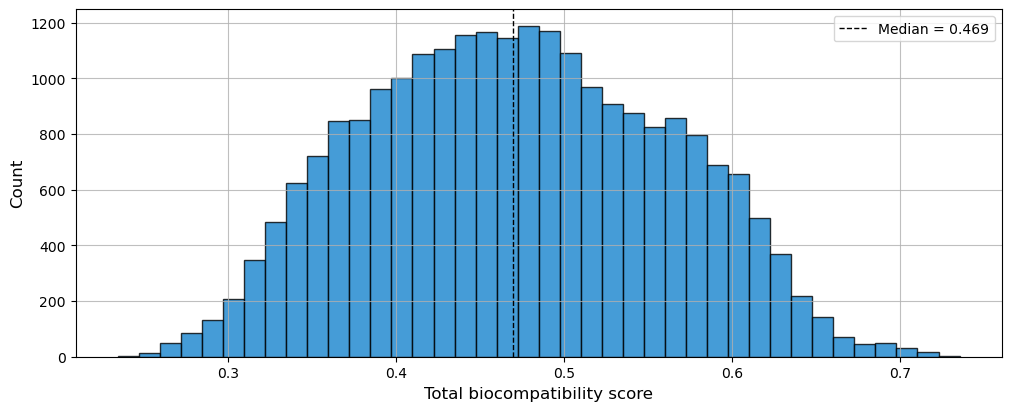

F7 plotted from 23469 valid scored rows | median=0.469366
min=0.234173 | max=0.735308 | mean=0.471468 | std=0.088764


In [17]:
# Figure F7: total biocompatibility score distribution (inline)
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if 'REPO_ROOT' in globals():
    REPO_ROOT_FIG = Path(REPO_ROOT).resolve()
else:
    _cwd = Path.cwd().resolve()
    REPO_ROOT_FIG = next(
        (p for p in [_cwd, *_cwd.parents] if (p / 'src').exists() and (p / 'data').exists()),
        _cwd,
    )
SCORES_PATH_FIG = REPO_ROOT_FIG / 'data' / 'interim' / 'generated_linker_scores.parquet'

if not SCORES_PATH_FIG.exists():
    raise FileNotFoundError(f'Missing input file: {SCORES_PATH_FIG}')

scores_df = pd.read_parquet(SCORES_PATH_FIG)
valid_scores = scores_df.loc[scores_df['total_score'].notna()].copy()
if valid_scores.empty:
    raise ValueError('No valid rows available to plot F7')

score_series = valid_scores['total_score'].dropna()
median_score = float(score_series.median())

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout = True)
ax.hist(score_series.values, bins = 40, color = "#1684ce", edgecolor = 'black', alpha = 0.8)
ax.axvline(
    median_score,
    color="black",
    linestyle='--',
    linewidth=1.0,
    label=f'Median = {median_score:.3f}',
)
ax.set_xlabel('Total biocompatibility score', fontsize = 12)
ax.set_ylabel('Count', fontsize = 12)
# ax.set_title('Figure F7. Total biocompatibility score distribution')
ax.grid(alpha=0.8)
ax.legend()

plt.savefig('total-biocomp.png', dpi = 800, format = 'png', bbox_inches = 'tight', transparent = True)
plt.show()
print(f'F7 plotted from {len(score_series)} valid scored rows | median={median_score:.6f}')
print(f'min={score_series.min():.6f} | max={score_series.max():.6f} | mean={score_series.mean():.6f} | std={score_series.std():.6f}')


### F8A: Visualize Drug-Tox Space (PCA + UMAP)

Color intensity encodes toxicity severity learned from GHS categories: cat 1 is highest toxicity, cat 5 is non-toxic.
The `single_smiles` used in Step 7 is projected onto the same latent maps.


C:\Users\ivan\AppData\Local\Temp\ipykernel_27636\2794742121.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')
c:\Users\ivan\Projects\PhD.NexterraReward\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


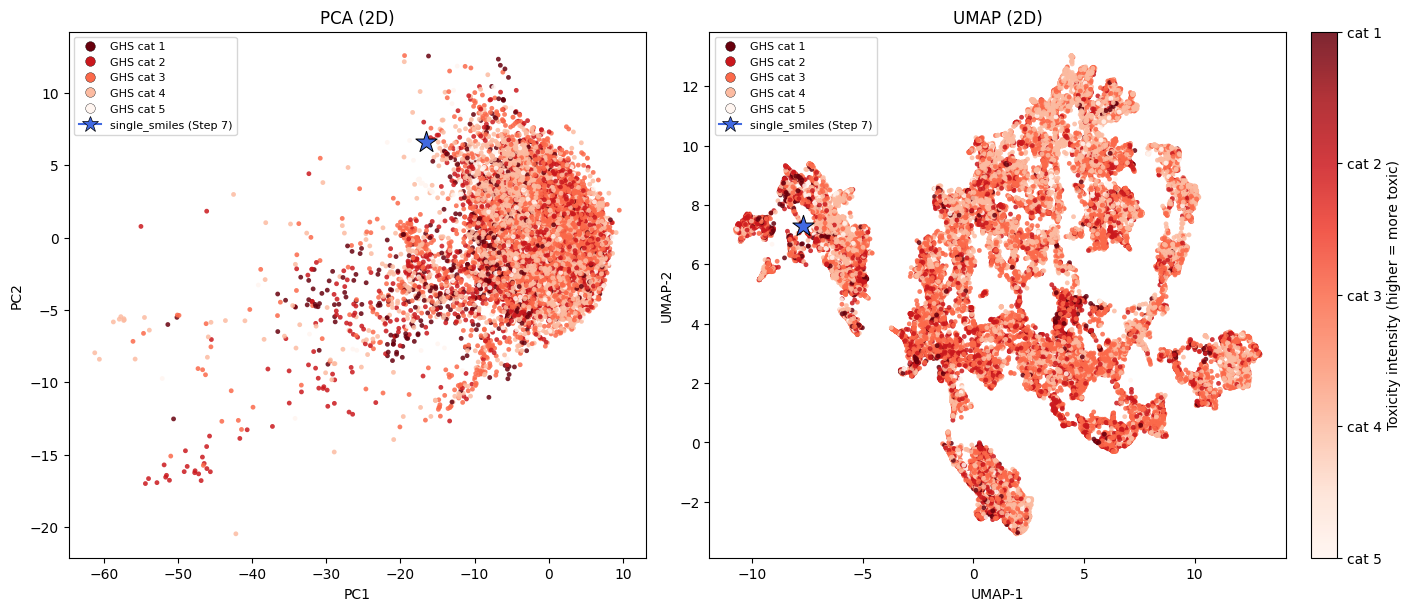

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import cm
from matplotlib.lines import Line2D

from src.drug_tox_space import load_drug_tox_space
from src.rdkit_features import compute_rdkit_features

if 'single_smiles' not in globals():
    raise RuntimeError('single_smiles is not defined. Run Step 7 first.')

if not DRUG_TOX_SPACE_FULL_PATH.exists():
    raise FileNotFoundError(f'Missing tox-space artifact: {DRUG_TOX_SPACE_FULL_PATH}')


def _pca_fit_transform_2d(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return a numerically stable PCA(2D) embedding (no sklearn dependency)."""
    work = np.asarray(matrix, dtype=float)
    if work.ndim != 2 or work.shape[0] < 2:
        raise ValueError(f'PCA expects a 2D matrix with >=2 rows, got shape={work.shape}')

    finite_mask = np.isfinite(work)
    if not finite_mask.all():
        work = work.copy()
        masked = np.where(finite_mask, work, np.nan)
        col_fill = np.nanmedian(masked, axis=0)
        col_fill = np.where(np.isfinite(col_fill), col_fill, 0.0)
        bad_rows, bad_cols = np.where(~finite_mask)
        work[bad_rows, bad_cols] = col_fill[bad_cols]

    mean_vec = work.mean(axis=0)
    centered = work - mean_vec

    if np.all(np.abs(centered) < 1e-12):
        components = np.zeros((2, centered.shape[1]), dtype=float)
        if centered.shape[1] >= 1:
            components[0, 0] = 1.0
        if centered.shape[1] >= 2:
            components[1, 1] = 1.0
        embedded = np.zeros((centered.shape[0], 2), dtype=float)
        return embedded, mean_vec, components

    col_scale = centered.std(axis=0)
    keep_mask = col_scale > 1e-12
    if int(keep_mask.sum()) == 0:
        components = np.zeros((2, centered.shape[1]), dtype=float)
        embedded = np.zeros((centered.shape[0], 2), dtype=float)
        return embedded, mean_vec, components

    scaled = centered[:, keep_mask] / col_scale[keep_mask]

    try:
        _, _, vt = np.linalg.svd(scaled, full_matrices=False)
        reduced = vt[:2, :]
    except np.linalg.LinAlgError:
        rng = np.random.default_rng(42)
        jitter = 1e-8 * rng.standard_normal(scaled.shape)
        try:
            _, _, vt = np.linalg.svd(scaled + jitter, full_matrices=False)
            reduced = vt[:2, :]
        except np.linalg.LinAlgError:
            cov = np.nan_to_num(scaled.T @ scaled, nan=0.0, posinf=0.0, neginf=0.0)
            evals, evecs = np.linalg.eigh(cov)
            order = np.argsort(evals)[::-1]
            reduced = evecs[:, order[:2]].T

    if reduced.shape[0] < 2:
        reduced = np.pad(reduced, ((0, 2 - reduced.shape[0]), (0, 0)), mode='constant')

    components = np.zeros((2, centered.shape[1]), dtype=float)
    components[:, keep_mask] = reduced[:2, :] / col_scale[keep_mask]
    embedded = np.nan_to_num(centered @ components.T, nan=0.0, posinf=0.0, neginf=0.0)
    return embedded, mean_vec, components

def _pca_transform_2d(vector: np.ndarray, mean_vec: np.ndarray, components: np.ndarray) -> np.ndarray:
    vec = np.asarray(vector, dtype=float)
    if vec.shape[0] != mean_vec.shape[0]:
        raise ValueError(
            f'Query vector length {vec.shape[0]} does not match PCA feature length {mean_vec.shape[0]}'
        )
    if not np.isfinite(vec).all():
        fill = np.where(np.isfinite(mean_vec), mean_vec, 0.0)
        vec = np.where(np.isfinite(vec), vec, fill)
    centered = vec - mean_vec
    return np.nan_to_num(centered @ components.T, nan=0.0, posinf=0.0, neginf=0.0)

tox_space = load_drug_tox_space(DRUG_TOX_SPACE_FULL_PATH)
X = np.asarray(tox_space.z_matrix, dtype=float)
cats = np.asarray(tox_space.ghs_categories, dtype=int)

if X.ndim != 2 or X.shape[0] != cats.shape[0]:
    raise ValueError(
        f'Invalid tox-space matrices: z_matrix shape={X.shape}, ghs_categories shape={cats.shape}'
    )

valid_mask = np.isin(cats, [1, 2, 3, 4, 5])
if int(valid_mask.sum()) == 0:
    raise ValueError('No valid GHS categories (1-5) available in tox space for plotting.')

X_plot = X[valid_mask]
cats_plot = cats[valid_mask]

include_3d = 'DipoleMoment' in tox_space.feature_names
query_feats, query_warn = compute_rdkit_features(
    single_smiles,
    include_fingerprints=False,
    include_3d=include_3d,
)
if query_warn:
    print(f'Step 8 query warnings: {len(query_warn)} warning(s)')

query_vec = np.array(
    [float(query_feats.get(name, np.nan)) for name in tox_space.feature_names],
    dtype=float,
)

nan_mask = np.isnan(query_vec)
if nan_mask.any():
    query_vec[nan_mask] = tox_space.feature_means[nan_mask]
    print(
        f'Step 8: imputed {int(nan_mask.sum())} missing query descriptors '
        'with tox-space feature means.'
    )

query_z = (query_vec - tox_space.feature_means) / tox_space.feature_stds

# Cat 1 -> intensity 5 (dark), Cat 5 -> intensity 1 (light)
tox_intensity = 6 - cats_plot
norm = mcolors.Normalize(vmin=1, vmax=5)
cmap = cm.get_cmap('Reds')

legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markerfacecolor=cmap(norm(6 - cat)),
        markeredgecolor='black',
        markeredgewidth=0.25,
        markersize=7,
        label=f'GHS cat {cat}',
    )
    for cat in [1, 2, 3, 4, 5]
]
legend_handles.append(
    Line2D(
        [0],
        [0],
        marker='*',
        color='royalblue',
        markerfacecolor='royalblue',
        markeredgecolor='black',
        markeredgewidth=0.5,
        markersize=12,
        label='single_smiles (Step 7)',
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# PCA panel
X_pca, pca_mean, pca_components = _pca_fit_transform_2d(X_plot)
query_pca = _pca_transform_2d(query_z, pca_mean, pca_components)

sc0 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=tox_intensity,
    cmap=cmap,
    norm=norm,
    s=12,
    alpha=0.85,
    linewidths=0,
)
axes[0].scatter(
    query_pca[0],
    query_pca[1],
    marker='*',
    s=260,
    color='royalblue',
    edgecolor='black',
    linewidth=0.7,
    zorder=5,
)
axes[0].set_title('PCA (2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(handles=legend_handles, loc='best', fontsize=8)

# UMAP panel (if available)
try:
    import umap.umap_ as umap

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric='euclidean',
        random_state=42,
    )
    X_umap = reducer.fit_transform(X_plot)
    query_umap = reducer.transform(query_z.reshape(1, -1))[0]

    axes[1].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        c=tox_intensity,
        cmap=cmap,
        norm=norm,
        s=12,
        alpha=0.85,
        linewidths=0,
    )
    axes[1].scatter(
        query_umap[0],
        query_umap[1],
        marker='*',
        s=260,
        color='royalblue',
        edgecolor='black',
        linewidth=0.7,
        zorder=5,
    )
    axes[1].set_title('UMAP (2D)')
    axes[1].set_xlabel('UMAP-1')
    axes[1].set_ylabel('UMAP-2')
    axes[1].legend(handles=legend_handles, loc='best', fontsize=8)
except Exception as e:
    axes[1].axis('off')
    axes[1].text(
        0.02,
        0.5,
        f'UMAP unavailable or failed:\n{type(e).__name__}: {e}',
        fontsize=10,
        va='center',
        ha='left',
    )

cbar = fig.colorbar(sc0, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label('Toxicity intensity (higher = more toxic)')
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.set_ticklabels(['cat 5', 'cat 4', 'cat 3', 'cat 2', 'cat 1'])

plt.show()



### F8B: Toxicity Landscape View (Heatmap)

Keeps the existing scatter charts and adds a latent-space heatmap.
The field is a smoothed local average of toxicity intensity (cat 1 = highest, cat 5 = non-toxic).


c:\Users\ivan\Projects\PhD.NexterraReward\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


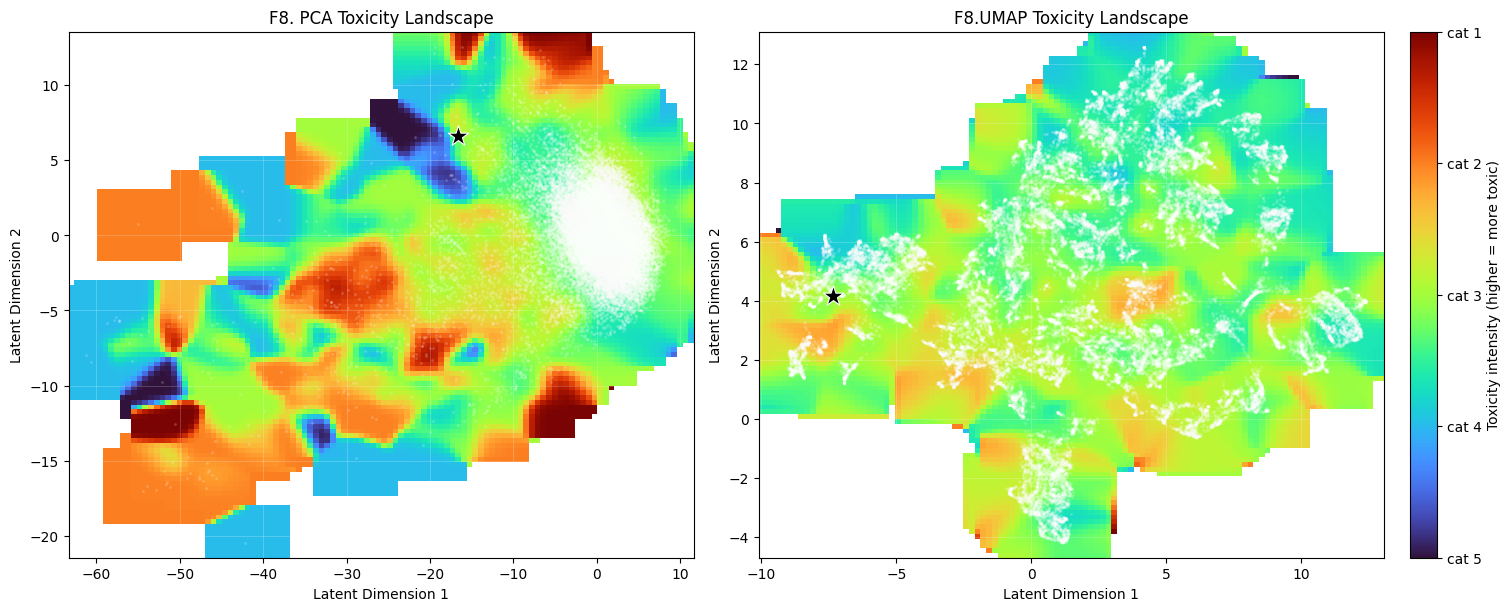

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from src.drug_tox_space import load_drug_tox_space
from src.rdkit_features import compute_rdkit_features

if 'single_smiles' not in globals():
    raise RuntimeError('single_smiles is not defined. Run Step 7 first.')


def _pca_fit_transform_2d(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return a numerically stable PCA(2D) embedding (no sklearn dependency)."""
    work = np.asarray(matrix, dtype=float)
    if work.ndim != 2 or work.shape[0] < 2:
        raise ValueError(f'PCA expects a 2D matrix with >=2 rows, got shape={work.shape}')

    finite_mask = np.isfinite(work)
    if not finite_mask.all():
        work = work.copy()
        masked = np.where(finite_mask, work, np.nan)
        col_fill = np.nanmedian(masked, axis=0)
        col_fill = np.where(np.isfinite(col_fill), col_fill, 0.0)
        bad_rows, bad_cols = np.where(~finite_mask)
        work[bad_rows, bad_cols] = col_fill[bad_cols]

    mean_vec = work.mean(axis=0)
    centered = work - mean_vec

    if np.all(np.abs(centered) < 1e-12):
        components = np.zeros((2, centered.shape[1]), dtype=float)
        if centered.shape[1] >= 1:
            components[0, 0] = 1.0
        if centered.shape[1] >= 2:
            components[1, 1] = 1.0
        embedded = np.zeros((centered.shape[0], 2), dtype=float)
        return embedded, mean_vec, components

    col_scale = centered.std(axis=0)
    keep_mask = col_scale > 1e-12
    if int(keep_mask.sum()) == 0:
        components = np.zeros((2, centered.shape[1]), dtype=float)
        embedded = np.zeros((centered.shape[0], 2), dtype=float)
        return embedded, mean_vec, components

    scaled = centered[:, keep_mask] / col_scale[keep_mask]

    try:
        _, _, vt = np.linalg.svd(scaled, full_matrices=False)
        reduced = vt[:2, :]
    except np.linalg.LinAlgError:
        rng = np.random.default_rng(42)
        jitter = 1e-8 * rng.standard_normal(scaled.shape)
        try:
            _, _, vt = np.linalg.svd(scaled + jitter, full_matrices=False)
            reduced = vt[:2, :]
        except np.linalg.LinAlgError:
            cov = np.nan_to_num(scaled.T @ scaled, nan=0.0, posinf=0.0, neginf=0.0)
            evals, evecs = np.linalg.eigh(cov)
            order = np.argsort(evals)[::-1]
            reduced = evecs[:, order[:2]].T

    if reduced.shape[0] < 2:
        reduced = np.pad(reduced, ((0, 2 - reduced.shape[0]), (0, 0)), mode='constant')

    components = np.zeros((2, centered.shape[1]), dtype=float)
    components[:, keep_mask] = reduced[:2, :] / col_scale[keep_mask]
    embedded = np.nan_to_num(centered @ components.T, nan=0.0, posinf=0.0, neginf=0.0)
    return embedded, mean_vec, components

def _pca_transform_2d(vector: np.ndarray, mean_vec: np.ndarray, components: np.ndarray) -> np.ndarray:
    vec = np.asarray(vector, dtype=float)
    if vec.shape[0] != mean_vec.shape[0]:
        raise ValueError(
            f'Query vector length {vec.shape[0]} does not match PCA feature length {mean_vec.shape[0]}'
        )
    if not np.isfinite(vec).all():
        fill = np.where(np.isfinite(mean_vec), mean_vec, 0.0)
        vec = np.where(np.isfinite(vec), vec, fill)
    centered = vec - mean_vec
    return np.nan_to_num(centered @ components.T, nan=0.0, posinf=0.0, neginf=0.0)

def _maybe_gaussian(arr: np.ndarray, sigma: float) -> np.ndarray:
    try:
        from scipy.ndimage import gaussian_filter

        return gaussian_filter(arr, sigma=sigma, mode='nearest')
    except Exception:
        return arr


def _build_landscape(
    embedding: np.ndarray,
    values: np.ndarray,
    *,
    bins: int = 110,
    sigma: float = 1.6,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = embedding[:, 0]
    y = embedding[:, 1]

    x_span = float(x.max() - x.min())
    y_span = float(y.max() - y.min())
    x_pad = 0.03 * (x_span if x_span > 0 else 1.0)
    y_pad = 0.03 * (y_span if y_span > 0 else 1.0)

    x_range = (float(x.min() - x_pad), float(x.max() + x_pad))
    y_range = (float(y.min() - y_pad), float(y.max() + y_pad))

    counts, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=(bins, bins),
        range=(x_range, y_range),
    )
    weighted, _, _ = np.histogram2d(
        x,
        y,
        bins=(bins, bins),
        range=(x_range, y_range),
        weights=values,
    )

    counts_s = _maybe_gaussian(counts, sigma=sigma)
    weighted_s = _maybe_gaussian(weighted, sigma=sigma)

    with np.errstate(divide='ignore', invalid='ignore'):
        field = weighted_s / counts_s

    field[counts_s <= 1e-8] = np.nan
    return xedges, yedges, field.T


def _query_vector_from_smiles(single_smi: str, tox_space) -> np.ndarray:
    include_3d = 'DipoleMoment' in tox_space.feature_names
    feats, warns = compute_rdkit_features(
        single_smi,
        include_fingerprints=False,
        include_3d=include_3d,
    )
    if warns:
        print(f'Step 8B query warnings: {len(warns)} warning(s)')

    vec = np.array(
        [float(feats.get(name, np.nan)) for name in tox_space.feature_names],
        dtype=float,
    )
    nan_mask = np.isnan(vec)
    if nan_mask.any():
        vec[nan_mask] = tox_space.feature_means[nan_mask]
        print(f'Step 8B: imputed {int(nan_mask.sum())} descriptor(s) with tox-space means.')

    return (vec - tox_space.feature_means) / tox_space.feature_stds


# Load latent tox context
space = load_drug_tox_space(DRUG_TOX_SPACE_FULL_PATH)
X = np.asarray(space.z_matrix, dtype=float)
cats = np.asarray(space.ghs_categories, dtype=int)
mask = np.isin(cats, [1, 2, 3, 4, 5])
if int(mask.sum()) == 0:
    raise ValueError('No GHS categories 1-5 available for plotting.')

X_plot = X[mask]
cats_plot = cats[mask]
tox_intensity = 6 - cats_plot  # cat1->5 (highest), cat5->1 (lowest)
qz = _query_vector_from_smiles(single_smiles, space)

# Embeddings
X_pca, pca_mean, pca_comp = _pca_fit_transform_2d(X_plot)
q_pca = _pca_transform_2d(qz, pca_mean, pca_comp)

umap_ok = True
try:
    import umap.umap_ as umap

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.12,
        metric='euclidean',
        random_state=42,
    )
    X_umap = reducer.fit_transform(X_plot)
    q_umap = reducer.transform(qz.reshape(1, -1))[0]
except Exception as e:
    umap_ok = False
    umap_error = f'{type(e).__name__}: {e}'

# Heatmap landscapes
xp, yp, zp = _build_landscape(X_pca, tox_intensity, bins=110, sigma=1.8)
if umap_ok:
    xu, yu, zu = _build_landscape(X_umap, tox_intensity, bins=110, sigma=1.8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

m0 = axes[0].pcolormesh(xp, yp, zp, shading='auto', cmap='turbo', vmin=1, vmax=5)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], s=4, c='white', alpha=0.20, linewidths=0)
axes[0].scatter(q_pca[0], q_pca[1], marker='*', s=240, c='black', edgecolor='white', linewidth=0.8, zorder=5)
axes[0].set_title('F8. PCA Toxicity Landscape')
axes[0].set_xlabel('Latent Dimension 1')
axes[0].set_ylabel('Latent Dimension 2')
axes[0].grid(color='white', alpha=0.35, linewidth=0.4)

if umap_ok:
    axes[1].pcolormesh(xu, yu, zu, shading='auto', cmap='turbo', vmin=1, vmax=5)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], s=4, c='white', alpha=0.20, linewidths=0)
    axes[1].scatter(q_umap[0], q_umap[1], marker='*', s=240, c='black', edgecolor='white', linewidth=0.8, zorder=5)
    axes[1].set_title('F8.UMAP Toxicity Landscape')
    axes[1].set_xlabel('Latent Dimension 1')
    axes[1].set_ylabel('Latent Dimension 2')
    axes[1].grid(color='white', alpha=0.35, linewidth=0.4)
else:
    axes[1].axis('off')
    axes[1].text(0.02, 0.5, f'UMAP unavailable:\\n{umap_error}', va='center', ha='left', fontsize=10)

cbar = fig.colorbar(m0, ax=axes.ravel().tolist(), fraction=0.032, pad=0.02)
cbar.set_label('Toxicity intensity (higher = more toxic)')
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.set_ticklabels(['cat 5', 'cat 4', 'cat 3', 'cat 2', 'cat 1'])

plt.show()



### F9A Score Components



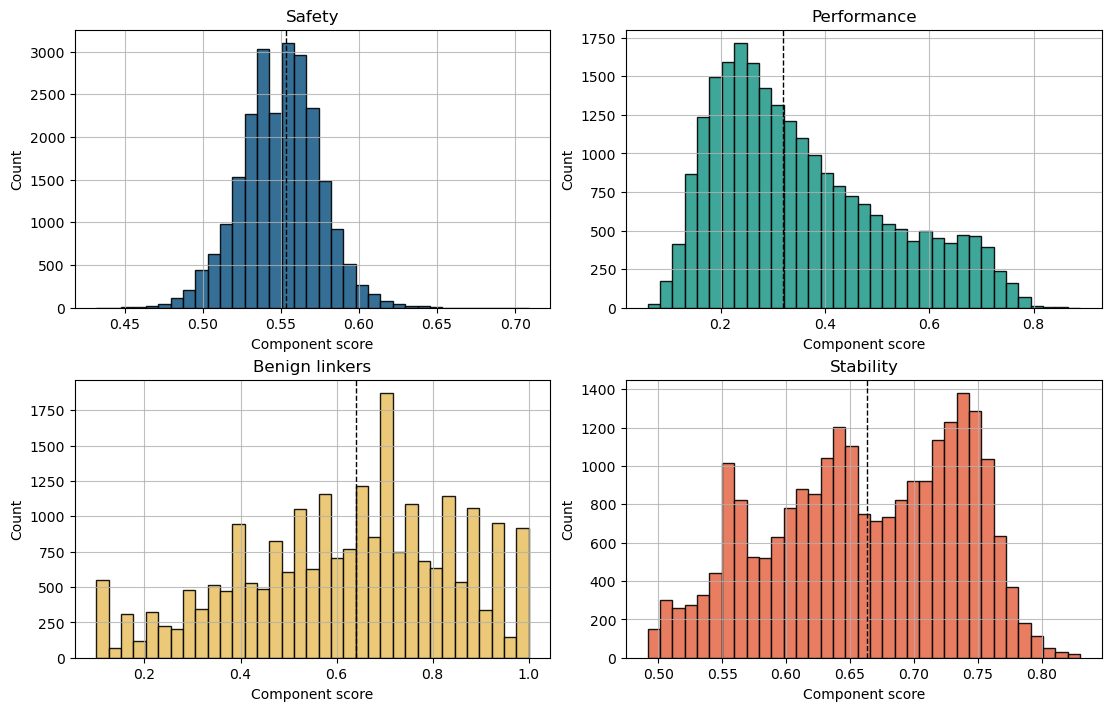

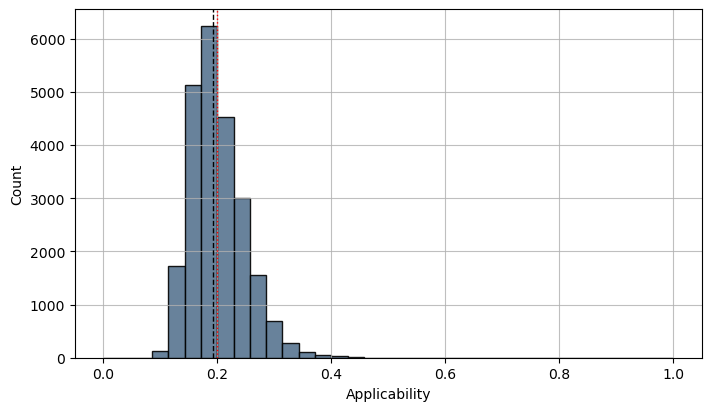

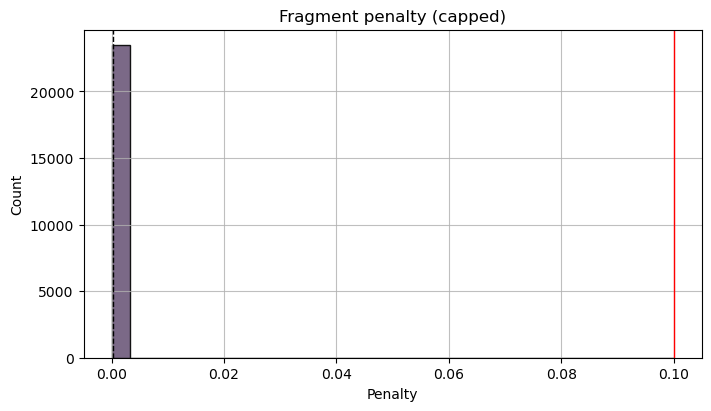

F9A/F9B/F9C plotted from 23469 valid scored rows
Component score ranges:
  Safety: min=0.431824, max=0.708671, median=0.552967, mean=0.549979, std=0.025067
  Performance: min=0.060453, max=0.888939, median=0.318862, mean=0.357588, std=0.165553
  Benign linkers: min=0.100000, max=1.000000, median=0.640000, mean=0.620436, std=0.220875
  Stability: min=0.491792, max=0.829849, median=0.663570, mean=0.661549, std=0.074441


In [19]:
# Figure F9A/F9B/F9C: split distributions (inline)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'REPO_ROOT' in globals():
    REPO_ROOT_FIG = Path(REPO_ROOT).resolve()
else:
    _cwd = Path.cwd().resolve()
    REPO_ROOT_FIG = next(
        (p for p in [_cwd, *_cwd.parents] if (p / 'src').exists() and (p / 'data').exists()),
        _cwd,
    )
SCORES_PATH_FIG = REPO_ROOT_FIG / 'data' / 'interim' / 'generated_linker_scores.parquet'

if not SCORES_PATH_FIG.exists():
    raise FileNotFoundError(f'Missing input file: {SCORES_PATH_FIG}')

scores_df = pd.read_parquet(SCORES_PATH_FIG)
valid_scores = scores_df.loc[scores_df['total_score'].notna()].copy()
if valid_scores.empty:
    raise ValueError('No valid rows available to plot F9')

# ----------------------------
# F9A: Core reward components
# ----------------------------
core_specs = [
    ('component_safety', 'Safety', 'Component score', '#1f5f8b', None),
    ('component_performance', 'Performance', 'Component score', '#2a9d8f', None),
    ('component_benign_linkers', 'Benign linkers', 'Component score', '#e9c46a', None),
    ('component_stability', 'Stability', 'Component score', '#e76f51', None),
]
missing_core = [col for col, *_ in core_specs if col not in valid_scores.columns]
if missing_core:
    raise ValueError(f'Missing expected F9A component columns: {missing_core}')

fig_a, axes_a = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for ax, (col, title, xlabel, color, bins) in zip(axes_a.flatten(), core_specs):
    series = pd.to_numeric(valid_scores[col], errors='coerce').dropna()
    hist_bins = bins if bins is not None else 35
    ax.hist(series.values, bins=hist_bins, edgecolor = 'black', color=color, alpha=0.9)
    ax.axvline(float(series.median()), color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.grid(alpha=0.8)
# fig_a.suptitle('Figure F9. Reward component distributions', fontsize=12)
plt.savefig('9A.png', dpi = 600, format = 'png', transparent = True)
plt.show()

# ----------------------------
# F9B: Toxicity applicability
# ----------------------------
col_app = 'feature_tox_applicability'
if col_app not in valid_scores.columns:
    raise ValueError(f'Missing expected F9B column: {col_app}')

series_app = pd.to_numeric(valid_scores[col_app], errors='coerce').dropna()
fig_b, ax_b = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
ax_b.hist(series_app.values, bins=np.linspace(0.0, 1.0, 36), edgecolor = 'black', color='#577590', alpha=0.9)
ax_b.axvline(float(series_app.median()), color='black', linestyle='--', linewidth=1)
ax_b.axvline(0.20, color='red', linestyle=':', linewidth=1)
# ax_b.set_title('Toxicity applicability')
ax_b.set_xlabel('Applicability')
ax_b.set_ylabel('Count')
ax_b.grid(alpha=0.8)
# fig_b.suptitle('Figure F9B. Toxicity applicability distribution', fontsize=12)
plt.savefig('9B.png', dpi = 600, format = 'png', transparent = True)
plt.show()

# ----------------------------
# F9C: Fragment penalty
# ----------------------------
col_pen = 'feature_fragment_penalty'
if col_pen not in valid_scores.columns:
    raise ValueError(f'Missing expected F9C column: {col_pen}')

series_pen = pd.to_numeric(valid_scores[col_pen], errors='coerce').dropna()
fig_c, ax_c = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
ax_c.hist(series_pen.values, bins=np.linspace(0.0, 0.10, 31), edgecolor = 'black', color='#6d597a', alpha=0.9)
ax_c.axvline(float(series_pen.median()), color='black', linestyle='--', linewidth=1)
ax_c.axvline(0.10, color='red', linestyle='-', linewidth=1)
ax_c.set_title('Fragment penalty (capped)')
ax_c.set_xlabel('Penalty')
ax_c.set_ylabel('Count')
ax_c.grid(alpha=0.8)
# fig_c.suptitle('Figure F9C. Fragment penalty distribution', fontsize=12)
plt.savefig('9C.png', dpi = 600, format = 'png', transparent = True)
plt.show()

print(f'F9A/F9B/F9C plotted from {len(valid_scores)} valid scored rows')
print(f'Component score ranges:')
for col, title, xlabel, color, bins in core_specs:
    series = pd.to_numeric(valid_scores[col], errors='coerce').dropna()
    print(f'  {title}: min={series.min():.6f}, max={series.max():.6f}, median={series.median():.6f}, mean={series.mean():.6f}, std={series.std():.6f}')


### F10 Known-Linker Validation

This diagnostic reproduces the earlier known-linker validation plot and compares top vs bottom score deciles.



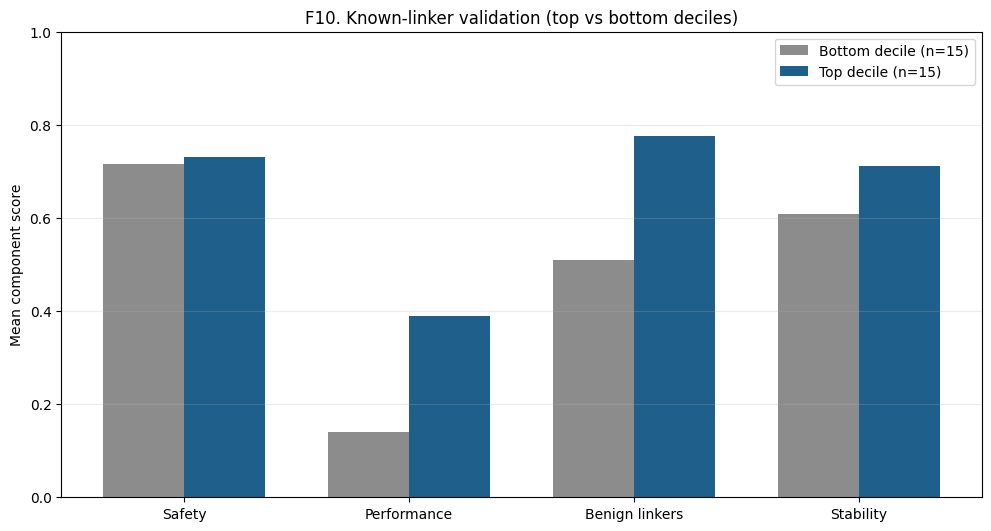

Known-linker valid rows=149 | decile size=15


,component,bottom_decile_mean,top_decile_mean,delta_top_minus_bottom
0,Safety,0.714736,0.730492,0.015756
1,Performance,0.140813,0.389153,0.248339
2,Benign linkers,0.509507,0.775797,0.266290
3,Stability,0.608772,0.710802,0.102030


In [15]:
# F10: known-linker validation (top vs bottom decile component contrast)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'REPO_ROOT' in globals():
    REPO_ROOT_FIG = Path(REPO_ROOT).resolve()
else:
    _cwd = Path.cwd().resolve()
    REPO_ROOT_FIG = next(
        (p for p in [_cwd, *_cwd.parents] if (p / 'src').exists() and (p / 'data').exists()),
        _cwd,
    )
KNOWN_LINKER_SCORES_PATH_FIG = REPO_ROOT_FIG / 'data' / 'interim' / 'generated_linker_scores_mof_properties_train.parquet'

if not KNOWN_LINKER_SCORES_PATH_FIG.exists():
    raise FileNotFoundError(f'Missing input file: {KNOWN_LINKER_SCORES_PATH_FIG}')

known_df = pd.read_parquet(KNOWN_LINKER_SCORES_PATH_FIG)
valid_known = known_df.loc[known_df['total_score'].notna()].copy().sort_values('total_score')
if valid_known.empty:
    raise ValueError('No valid rows available for legacy F10 known-linker validation')

component_cols = ['component_safety', 'component_performance', 'component_benign_linkers', 'component_stability']
for c in component_cols:
    if c not in valid_known.columns:
        raise ValueError(f'Missing expected component column: {c}')

k = max(1, int(round(len(valid_known) * 0.1)))
low_decile = valid_known.head(k)
high_decile = valid_known.tail(k)

low_means = [float(low_decile[c].mean()) for c in component_cols]
high_means = [float(high_decile[c].mean()) for c in component_cols]
delta = [h - l for h, l in zip(high_means, low_means)]

x = np.arange(len(component_cols))
width = 0.36
fig, ax = plt.subplots(figsize=(9.8, 5.2), constrained_layout=True)
ax.bar(x - width / 2, low_means, width, label=f'Bottom decile (n={k})', color='#8c8c8c')
ax.bar(x + width / 2, high_means, width, label=f'Top decile (n={k})', color='#1f5f8b')
ax.set_xticks(x)
ax.set_xticklabels(['Safety', 'Performance', 'Benign linkers', 'Stability'])
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('Mean component score')
ax.set_title('F10. Known-linker validation (top vs bottom deciles)')
ax.grid(axis='y', alpha=0.25)
ax.legend()

plt.show()

summary_df = pd.DataFrame({
    'component': ['Safety', 'Performance', 'Benign linkers', 'Stability'],
    'bottom_decile_mean': low_means,
    'top_decile_mean': high_means,
    'delta_top_minus_bottom': delta,
})
print(f'Known-linker valid rows={len(valid_known)} | decile size={k}')
display(summary_df)


### F11 Domain View

The payload-tailoring landscape highlights how reward quality depends on polarity-hydrophobicity balance.


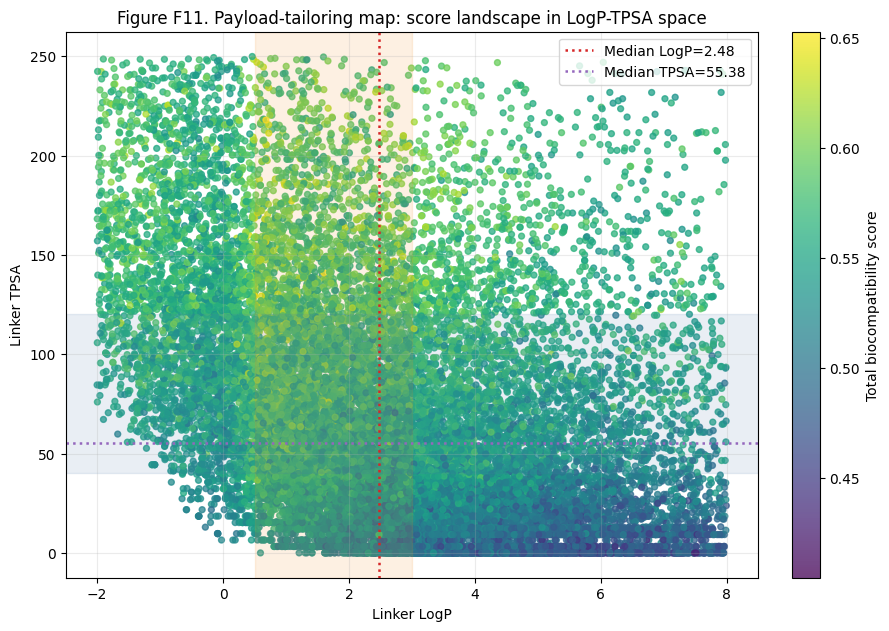

F11 plotted from 22080 filtered rows (valid scored rows=25000)
Medians -> LogP: 2.479080, TPSA: 55.380000, total_score: 0.548210
Descriptive statistics (filtered F11 dataset):


,count,mean,std,min,25%,median,75%,max
feature_logP,22080.000000,2.617382,2.186344,-1.999320,1.029725,2.479080,4.098965,7.991660
feature_TPSA,22080.000000,70.212947,57.884536,0.000000,23.550000,55.380000,105.360000,249.850000
total_score,22080.000000,0.544653,0.035023,0.404618,0.521206,0.548210,0.570200,0.652716


In [16]:
# Figure F11: payload-tailoring map with median/descriptive statistics (inline)
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if 'REPO_ROOT' in globals():
    REPO_ROOT_FIG = Path(REPO_ROOT).resolve()
else:
    _cwd = Path.cwd().resolve()
    REPO_ROOT_FIG = next(
        (p for p in [_cwd, *_cwd.parents] if (p / 'src').exists() and (p / 'data').exists()),
        _cwd,
    )
SCORES_PATH_FIG = REPO_ROOT_FIG / 'data' / 'interim' / 'generated_linker_scores.parquet'

if not SCORES_PATH_FIG.exists():
    raise FileNotFoundError(f'Missing input file: {SCORES_PATH_FIG}')

scores_df = pd.read_parquet(SCORES_PATH_FIG)
valid_scores = scores_df.loc[scores_df['total_score'].notna()].copy()

required_cols = ['feature_logP', 'feature_TPSA', 'total_score']
for c in required_cols:
    if c not in valid_scores.columns:
        raise ValueError(f'Missing expected column for F11: {c}')

payload_df = valid_scores[required_cols].dropna().copy()
payload_df = payload_df[
    payload_df['feature_logP'].between(-2.0, 8.0)
    & payload_df['feature_TPSA'].between(0.0, 250.0)
]
if payload_df.empty:
    raise ValueError('No data available to plot F11 payload-tailoring map after filtering')

median_logp = float(payload_df['feature_logP'].median())
median_tpsa = float(payload_df['feature_TPSA'].median())
median_score = float(payload_df['total_score'].median())

desc = payload_df[['feature_logP', 'feature_TPSA', 'total_score']].describe(
    percentiles=[0.25, 0.5, 0.75]
).T

desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc = desc.rename(columns={'50%': 'median'})

fig, ax = plt.subplots(figsize=(8.8, 6.2), constrained_layout=True)
scatter = ax.scatter(
    payload_df['feature_logP'],
    payload_df['feature_TPSA'],
    c=payload_df['total_score'],
    s=18,
    cmap='viridis',
    alpha=0.75,
)
# Default desirability windows and medians
ax.axvspan(0.5, 3.0, color='#f58518', alpha=0.12)
ax.axhspan(40.0, 120.0, color='#4c78a8', alpha=0.12)
ax.axvline(median_logp, color='#d62728', linestyle=':', linewidth=1.8, label=f'Median LogP={median_logp:.2f}')
ax.axhline(median_tpsa, color='#9467bd', linestyle=':', linewidth=1.8, label=f'Median TPSA={median_tpsa:.2f}')

ax.set_xlabel('Linker LogP')
ax.set_ylabel('Linker TPSA')
ax.set_title('Figure F11. Payload-tailoring map: score landscape in LogP-TPSA space')
ax.grid(alpha=0.25)
ax.legend(loc='upper right')
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label('Total biocompatibility score')

plt.show()
print(f'F11 plotted from {len(payload_df)} filtered rows (valid scored rows={len(valid_scores)})')
print(f'Medians -> LogP: {median_logp:.6f}, TPSA: {median_tpsa:.6f}, total_score: {median_score:.6f}')
print('Descriptive statistics (filtered F11 dataset):')
display(desc)
